In [40]:
import sys
sys.path.append('../')

from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.datasets import make_friedman1, make_friedman2, make_friedman3
import matplotlib.pyplot as plt
import xgboost as xgb #baseline
from utils import *

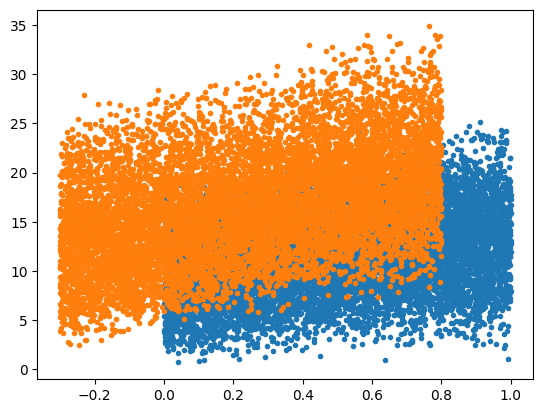

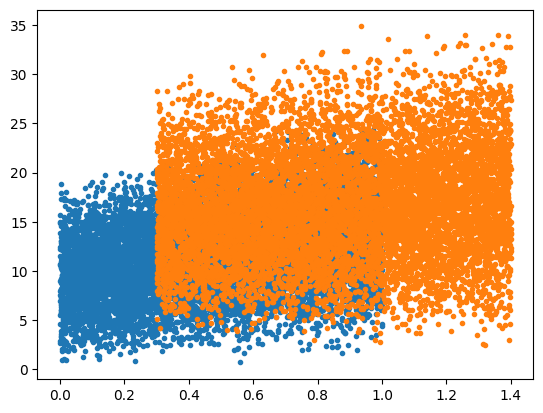

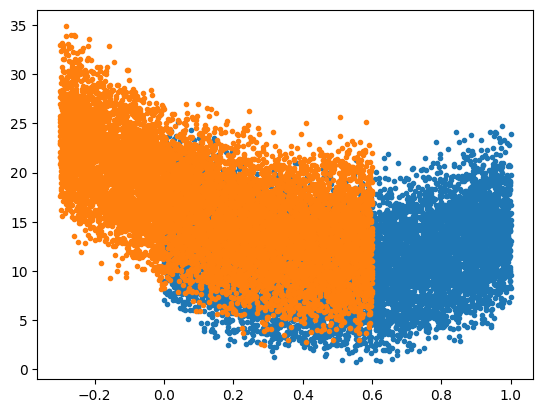

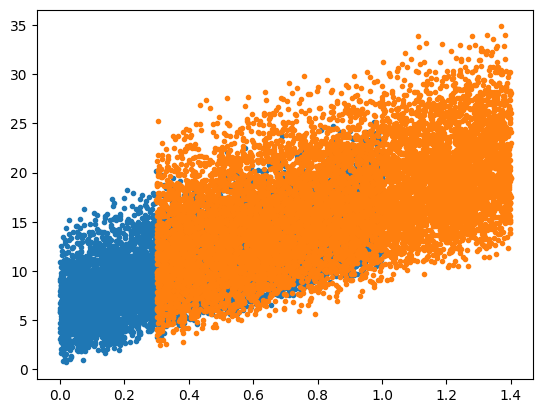

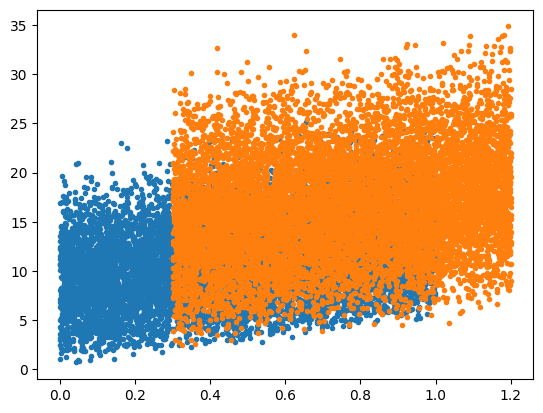

In [ ]:
def friedman1(n_samples, noise = 0.0, n_features = 5):
    x0 = np.random.uniform(0,1,size=n_samples)
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples)
    x3 = np.random.uniform(0,1,size=n_samples)
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4 + noise*np.random.normal(0,1,size = n_samples) 

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y

def friedman1_altered(n_samples, noise=0.0, n_features=5,
                      altering_level=0.1, constant_level=0.05,
                      pred_alter=0.1, pred_constant=10,
                      shift_seed=None):
    
    # Create separate random generator for deterministic shifts
    shift_rng = np.random.RandomState(shift_seed)
    
    # Apply fixed (seeded) scaling and shifting factors
    scale_factors = 1 + altering_level * shift_rng.choice([-1, 1], size=5)
    shift_constants = constant_level * shift_rng.choice([-1, 1], size=5)

    # Generate base features with standard randomness
    x0 = np.random.uniform(0,1,size=n_samples) * scale_factors[0] + shift_constants[0]
    x1 = np.random.uniform(0,1,size=n_samples) * scale_factors[1] + shift_constants[1]
    x2 = np.random.uniform(0,1,size=n_samples) * scale_factors[2] + shift_constants[2]
    x3 = np.random.uniform(0,1,size=n_samples) * scale_factors[3] + shift_constants[3]
    x4 = np.random.uniform(0,1,size=n_samples) * scale_factors[4] + shift_constants[4]

    X = np.column_stack((x0, x1, x2, x3, x4))
    
    # Apply fixed (seeded) shift for prediction
    pred_scale = 1 + pred_alter * shift_rng.choice([-1, 1])
    pred_shift = pred_constant * shift_rng.choice([-1, 1])

    y = (10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4) * pred_scale + pred_shift
    y += noise * np.random.normal(0, 1, size=n_samples)

    # Add noise features if needed
    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y



X, y = friedman1(10000, noise = 0.0, n_features=10)
noise = np.mean(y - np.median(y))
X_altered, y_altered= friedman1_altered(n_samples=10000, noise=noise, 
                                                   n_features=10, altering_level = 0.1, constant_level = 0.3, pred_alter=0.1, pred_constant=0.3) 

plt.plot(X[:,0], y, '.')
plt.plot(X_altered[:,0], y_altered, '.')
plt.show()

plt.plot(X[:,1], y, '.')
plt.plot(X_altered[:,1], y_altered, '.')
plt.show()

plt.plot(X[:,2], y, '.')
plt.plot(X_altered[:,2], y_altered, '.')
plt.show()

plt.plot(X[:,3], y, '.')
plt.plot(X_altered[:,3], y_altered, '.')
plt.show()

plt.plot(X[:,4], y, '.')
plt.plot(X_altered[:,4], y_altered, '.')
plt.show()


In [54]:
def train_xgboost(data_train, labels_train, boosting_rounds, params):

    dtrain = xgb.DMatrix(data_train, label=labels_train)

    # Train with evaluation set and early stopping
    evallist = [(dtrain, 'train')]

    bst = xgb.train(params, dtrain, num_boost_round=boosting_rounds, evals=evallist, verbose_eval=False)

    return bst

def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

In [ ]:
#ablation study for transfertreeboost
ablation_transfer = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse',
                                   'mae', 'source_tree_size', 'target_tree_size', 'v', 'tau', 'epochs'])

alter_list = [0.05, 0.15, 0.25]
constant_list = [0.1, 0.3, 0.5]
seed_list = [1,2,3]
epoch_list = [200,300]
v_list = [0.05, 0.1]
source_tree_size_list = [1,2,3]
target_tree_size_list = [1,2,3]
tau_list = [0.97, 0.99]
for seed in seed_list:
    disturbance_level  = 0
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_target_test, y_target_test = friedman1(n_samples=10000, noise=0.2, n_features=10) 
        X_target_train, y_target_train = friedman1(n_samples=300, noise=0.0, n_features=10)
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, noise=0.2, 
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed) 
        
        for epochs in epoch_list:
            for v in v_list:
                for source_tree_size in source_tree_size_list:
                    for target_tree_size in target_tree_size_list:
                        for tau in tau_list:

        
                            fiter = LSTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                                        target_tree_size=target_tree_size)
                            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
                            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
                            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

                            ablation_transfer.loc[len(ablation_transfer)] = [seed, disturbance_level, rmse,
                                   mae, source_tree_size, target_tree_size, v, tau, epochs]
                            ablation_transfer.to_csv('ablation_transfer.csv')
                            
        



In [ ]:
#ablation study for xgboost
ablation_xgboost = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse',
                                   'mae', 'tree_size', 'v', 'epochs'])

alter_list = [0.05, 0.15, 0.25]
constant_list = [0.1, 0.3, 0.5]
seed_list = [1,2,3]
epoch_list = [100, 200,300,400,500,600]
v_list = [0.05, 0.1, 0.15, 0.2]
tree_size_list = [1,2,3,4,5]
for seed in seed_list:
    disturbance_level  = 0
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_target_test, y_target_test = friedman1(n_samples=10000, noise=0.2, n_features=10) 
        X_target_train, y_target_train = friedman1(n_samples=300, noise=0.0, n_features=10)
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, noise=0.2, 
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed) 
        
        for epochs in epoch_list:
            for v in v_list:
                for tree_size in tree_size_list:

        
        
                    params = {
                        'objective': 'reg:squarederror',  # Regression with squared error
                        'max_depth': tree_size,                   # Maximum depth of a tree
                        'eta': v,                       # Learning rate
                        'eval_metric': 'rmse',           # RMSE as evaluation metric
                    }
                    
                    bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=epochs, params=params)
                    preds = test_xgboost(X_target_test, bst)
                    rmse = compute_rmse(preds, y_target_test)
                    mae = compute_mae(preds, y_target_test)
                    ablation_xgboost.loc[len(ablation_xgboost)] = [seed, disturbance_level, rmse,
                                            mae, tree_size, v, epochs]
                    ablation_xgboost.to_csv('ablation_xgboost.csv')

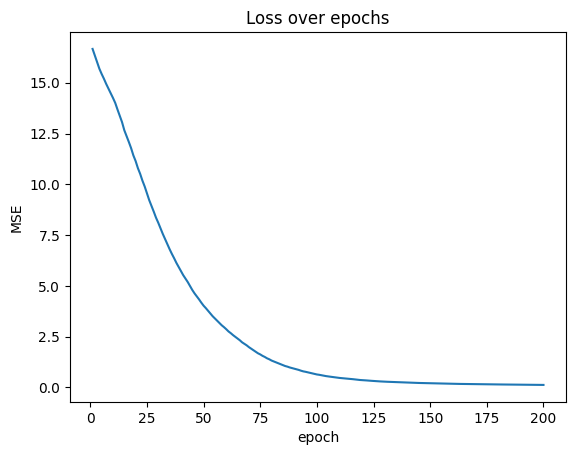

0.7692399245704836


In [ ]:
#MTreeBoost is under development
fiter = LSTransferTreeBoost(epochs=200, v=0.1, decay_factor=0.99, source_tree_size=3, target_tree_size=3)
y = np.concatenate((y_source_train, y_target_train))
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, show_curves=True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
print(rmse)


In [ ]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
}

def train_xgboost(data_train, labels_train, boosting_rounds):

    dtrain = xgb.DMatrix(data_train, label=labels_train)

    # Train with evaluation set and early stopping
    evallist = [(dtrain, 'train')]

    bst = xgb.train(params, dtrain, num_boost_round=boosting_rounds, evals=evallist)

    return bst

def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

X = np.concatenate((X_source_train, X_target_train))
bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=200)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
print(rmse)

[0]	train-rmse:3.90799
[1]	train-rmse:3.70915
[2]	train-rmse:3.53739
[3]	train-rmse:3.37727
[4]	train-rmse:3.24130
[5]	train-rmse:3.11295
[6]	train-rmse:3.00289
[7]	train-rmse:2.89791
[8]	train-rmse:2.80256
[9]	train-rmse:2.71482
[10]	train-rmse:2.63022
[11]	train-rmse:2.55449
[12]	train-rmse:2.48480
[13]	train-rmse:2.41422
[14]	train-rmse:2.33292
[15]	train-rmse:2.27337
[16]	train-rmse:2.21586
[17]	train-rmse:2.16269
[18]	train-rmse:2.10172
[19]	train-rmse:2.04741
[20]	train-rmse:1.99656
[21]	train-rmse:1.94190
[22]	train-rmse:1.89780
[23]	train-rmse:1.84911
[24]	train-rmse:1.79430
[25]	train-rmse:1.75224
[26]	train-rmse:1.71350
[27]	train-rmse:1.67127
[28]	train-rmse:1.63250
[29]	train-rmse:1.59412
[30]	train-rmse:1.55976
[31]	train-rmse:1.52128
[32]	train-rmse:1.48903
[33]	train-rmse:1.45844
[34]	train-rmse:1.42799
[35]	train-rmse:1.39842
[36]	train-rmse:1.37040
[37]	train-rmse:1.33848
[38]	train-rmse:1.30430
[39]	train-rmse:1.27701
[40]	train-rmse:1.25185
[41]	train-rmse:1.22404
[4

In [ ]:
for epochs in epoch_list:
            for v in v_list:
                for source_tree_size in source_tree_size_list:
                    for target_tree_size in target_tree_size_list:
                        for tau in tau_list: